In [ ]:
import pandas as pd
import lasio
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
las2= lasio.read("./LAS/Ichthys_1A_S3_R1_AIT_LDS_APS_ECS_HNGS_Main_Field.las",  engine='normal', use_normal_engine_for_wrapped=True)
las4= lasio.read("./LAS/Ichthys_1A_S3_R4_DSI_OBMI_EMS_Main.las", engine='normal' , use_normal_engine_for_wrapped=True)

In [ ]:
df02 = las2.df()
df04 = las4.df()

In [ ]:
df02.reset_index(inplace = True)
df04.reset_index(inplace = True)

In [ ]:
df02.columns

Index(['DEPTH', 'BS', 'CS', 'TENS', 'ETIM', 'RT', 'HTHO', 'HURA', 'HFK',
       'HBHK', 'HSGR', 'HCGR', 'HTPR', 'HTUR', 'HUPR', 'DF', 'DCAL', 'FCD',
       'HDAR', 'RHOM', 'DRH', 'PEFL', 'LCAL', 'FPLC', 'APLC', 'SIGF', 'CALM',
       'CNC', 'RHGE', 'TIME:1', 'CVEL', 'CDF', 'IHV', 'ICV', 'AO10', 'AO20',
       'AO30', 'AO90', 'AT10', 'AT20', 'AT30', 'AT60', 'AT90', 'AF10', 'AF20',
       'AF30', 'AF60', 'AF90', 'AFRT', 'AFRX', 'AORT', 'AORX', 'ATD1', 'ATD2',
       'ATRT', 'ATRX', 'TIME:2'],
      dtype='object')

In [ ]:
df04.columns

Index(['DEPTH', 'BS', 'CS', 'TENS', 'ETIM', 'ITT', 'DTCO', 'DTSM', 'PR',
       'VPVS', 'CHR1', 'DT1R', 'CHR2', 'DT2R', 'CHR3', 'DT3R', 'DTRP', 'CHRP',
       'DTRS', 'CHRS', 'DTTP', 'CHTP', 'DTTS', 'CHTS', 'DT1', 'DT2', 'DTST',
       'DT4P', 'DT4S', 'DT5', 'P1NO_OBMT', 'DEVI', 'RB_OBMT', 'P1AZ_OBMT',
       'ANOR', 'HAZI', 'P1AZ', 'RB', 'SDEV', 'DCAL', 'FCD', 'HDAR', 'HD1',
       'HD2', 'HD3', 'RD1', 'RD2', 'RD3', 'RD4', 'RD5', 'RD6', 'ECGR', 'DF',
       'ELA', 'ESA', 'ERA', 'ECD', 'TIME:1', 'CVEL', 'FNOR', 'IHV', 'ICV',
       'CDF', 'GR', 'C1_OBMT', 'C2_OBMT', 'AX', 'AY', 'AZ', 'TIME:2', 'FX',
       'FY', 'FZ', 'DPTR', 'DPAZ', 'TIME:3', 'QUAF'],
      dtype='object')

In [ ]:
df02= df02.rename( columns= {
    'APLC':'NPHI',
    'AT90': 'ILD',
    'AT30': 'ILM',
    'AT10': 'ILS' ,
    'RHOM': 'RHOB',
    'LCAL': 'CALI',
    'HSGR': 'GR'} )

In [ ]:
df02= df02.dropna(subset=['RHOB', 'NPHI', 'GR', 'ILD'])

In [ ]:
df04= df04.dropna(subset=['DTCO','DTSM'])

In [ ]:
top_depth= 4213.6
bottom_depth= 4527

In [ ]:
df2=df02[(df02['DEPTH']>=top_depth) & (df02['DEPTH']<=bottom_depth)].copy()

df2=df2.reset_index(drop=True)

In [ ]:
df4=df04[(df04['DEPTH']>=top_depth) & (df04['DEPTH']<=bottom_depth)].copy()

df4=df4.reset_index(drop=True)

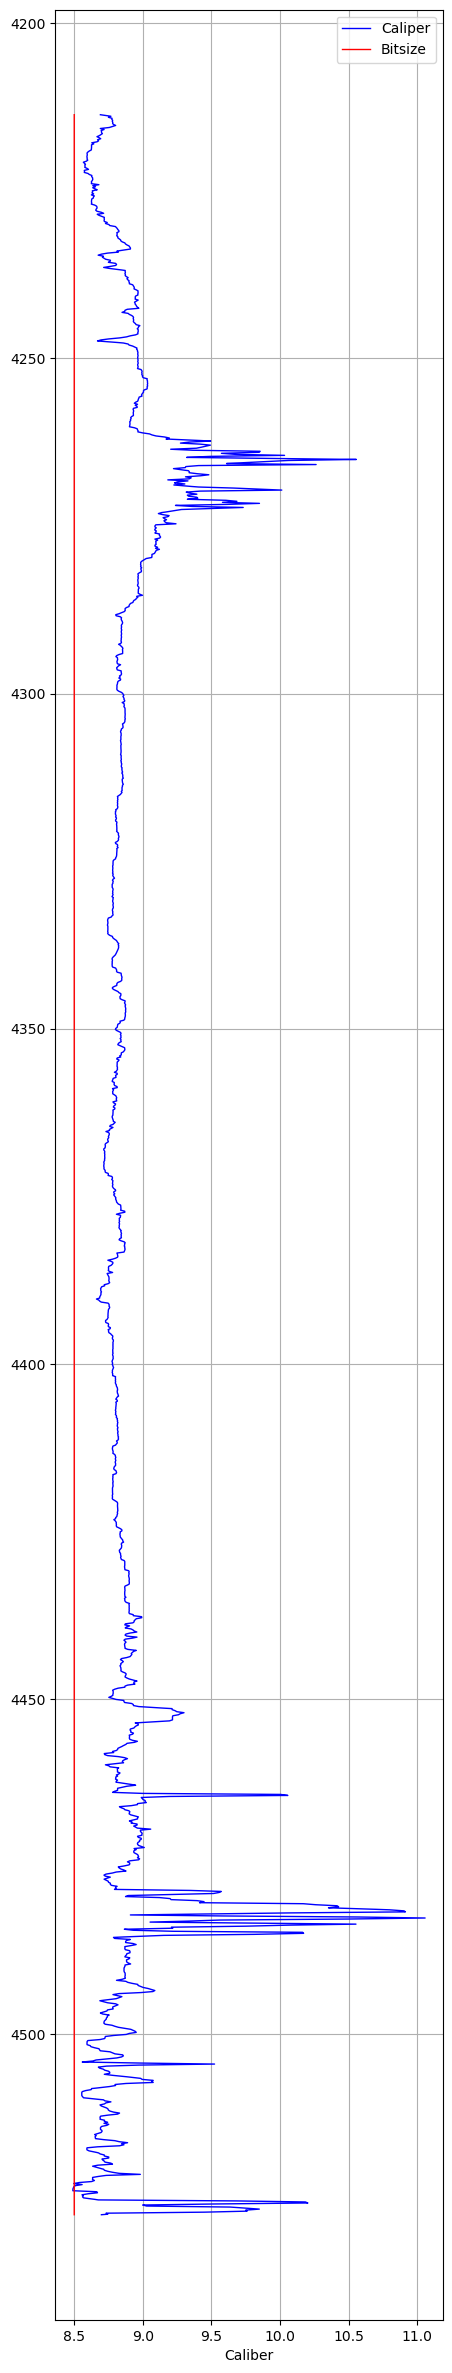

In [ ]:
fig, ax= plt.subplots(figsize=(5,30))

ax.plot(df2['CALI'], df2['DEPTH'],color='blue', label= 'Caliper', lw=1)
ax.plot(df2['BS'], df2['DEPTH'], color='red', label= 'Bitsize', lw=1)
ax.set_xlabel('Caliber')
ax.grid()

ax.legend()
plt.gca().invert_yaxis()

In [ ]:
df2['RHOB_smooth'] = df2['RHOB'].rolling(window=20, center=True).median()
df2['NPHI_smooth'] = df2['NPHI'].rolling(window=20, center=True).median()
df2['GR_smooth'] = df2['GR'].rolling(window=10, center=True).median()

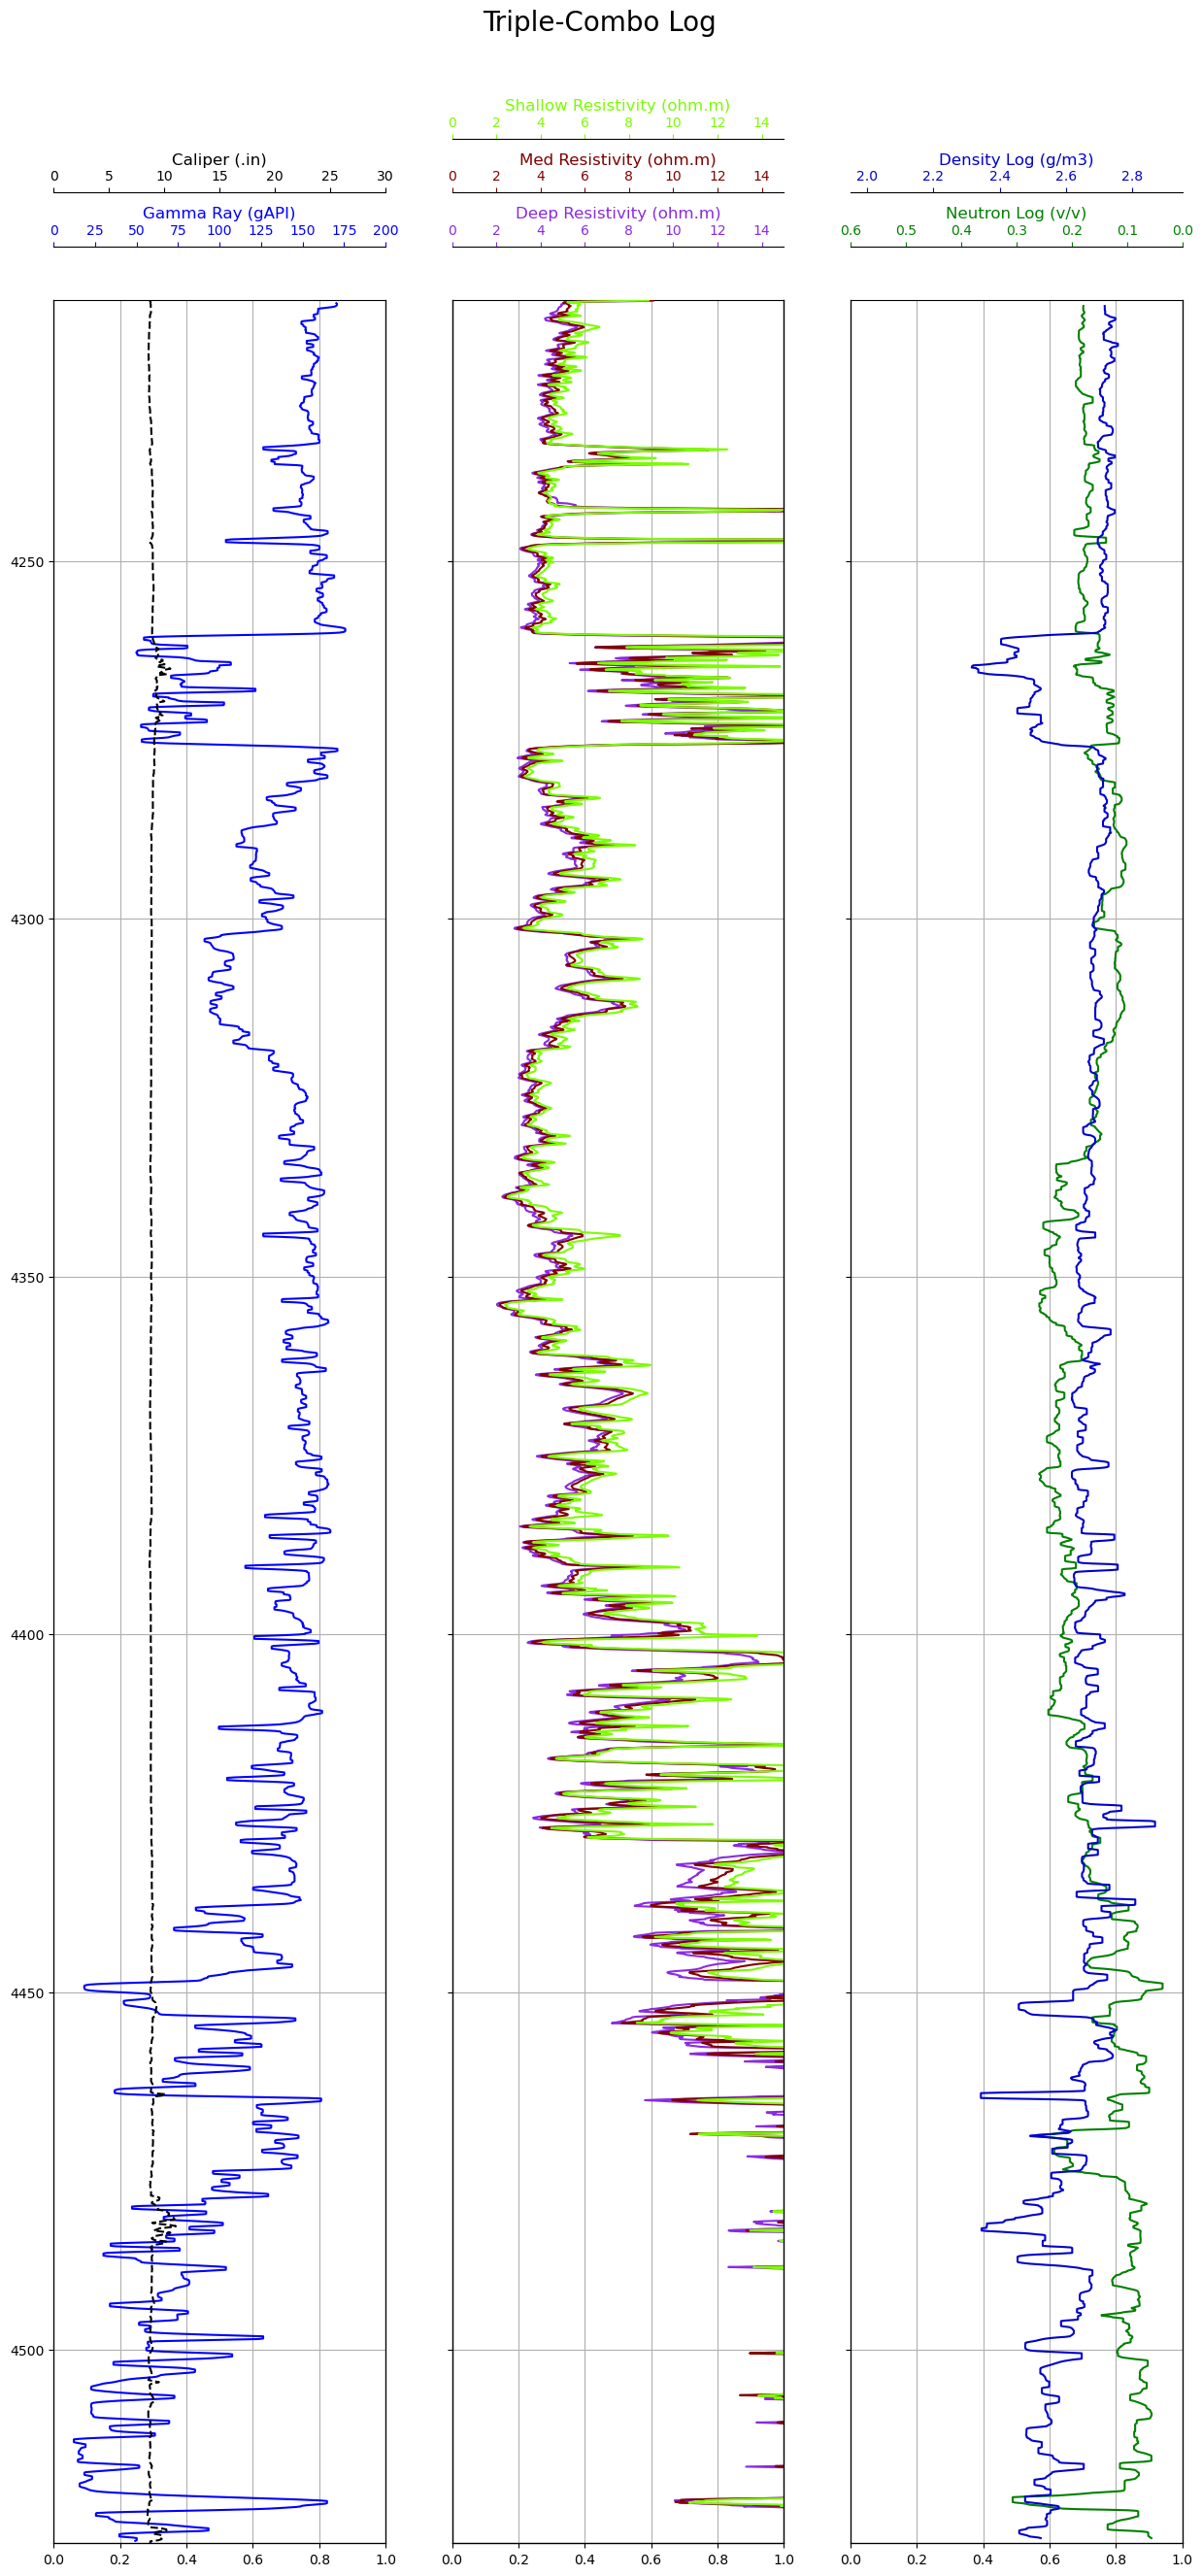

In [ ]:
#Triple-Combo-Plot

fig, ac= plt.subplots(1,3,figsize=(15,30), sharey=True)

fig.suptitle('Triple-Combo Log', fontsize=20)
for axes in ac:
        axes.set_ylim(top_depth, bottom_depth)

ac2=ac[0].twiny()
ac2.plot(df2['GR_smooth'],df2['DEPTH'],color='blue')
ac2.set_xlim(0,200)
ac2.spines['top'].set_position(('outward',40))
ac2.set_xlabel('Gamma Ray (gAPI)',color='blue',fontsize=12)
ac2.tick_params(axis='x',colors='blue')

ac1=ac[0].twiny()
ac1.plot(df2['CALI'],df2['DEPTH'],color='black',linestyle='--')
ac1.set_xlim(0,30)
ac1.spines['top'].set_position(('outward',80))
ac1.set_xlabel('Caliper (.in)',color='black',fontsize=12)
ac1.tick_params(axis='x',colors='black')
ac[0].grid(True)


ac11=ac[1].twiny()
ac11.plot(df2['ILD'],df2['DEPTH'],color='blueviolet')
ac11.set_xlim(0,15)
ac11.spines['top'].set_position(('outward',40))
ac11.set_xlabel('Deep Resistivity (ohm.m)',color='blueviolet',fontsize=12)
ac11.tick_params(axis='x',colors='blueviolet')

ac12=ac[1].twiny()
ac12.plot(df2['ILM'],df2['DEPTH'],color='maroon')
ac12.set_xlim(0,15)
ac12.spines['top'].set_position(('outward',80))
ac12.set_xlabel('Med Resistivity (ohm.m)',color='maroon',fontsize=12)
ac12.tick_params(axis='x',colors='maroon')

ac13=ac[1].twiny()
ac13.plot(df2['ILS'],df2['DEPTH'],color='lawngreen')
ac13.set_xlim(0,15)
ac13.spines['top'].set_position(('outward',120))
ac13.set_xlabel('Shallow Resistivity (ohm.m)',color='lawngreen',fontsize=12)
ac13.tick_params(axis='x',colors='lawngreen')
ac[1].grid(True)


ac21=ac[2].twiny()
ac21.plot(df2['NPHI_smooth'],df2['DEPTH'],color='green')
ac21.set_xlim(0,0.6)
ac21.invert_xaxis()
ac21.spines['top'].set_position(('outward',40))
ac21.set_xlabel('Neutron Log (v/v)',color='green',fontsize=12)
ac21.tick_params(axis='x',colors='green')

ac22=ac[2].twiny()
ac22.plot(df2['RHOB_smooth'],df2['DEPTH'],color='mediumblue')
ac22.set_xlim(1.95,2.95)
ac22.spines['top'].set_position(('outward',80))
ac22.set_xlabel('Density Log (g/m3)',color='mediumblue',fontsize=12)
ac22.tick_params(axis='x',colors='mediumblue')
ac[2].grid(True)

plt.gca().invert_yaxis()

In [ ]:
# Sandstone matrix constants
rho_ma = 2.65   # g/cc
rho_f = 1.0     # g/cc

dt_ma = 55.5    # us/ft
dt_f = 189      # us/ft

In [ ]:
df2['PHI_N']= df2['NPHI_smooth'] - 0.04

In [ ]:
df2['PHI_D']= (rho_ma-df2['RHOB_smooth'])/(rho_ma-rho_f)

In [ ]:
df2['PHI_T']= 0.5*(df2['PHI_N']+ df2['PHI_D'])

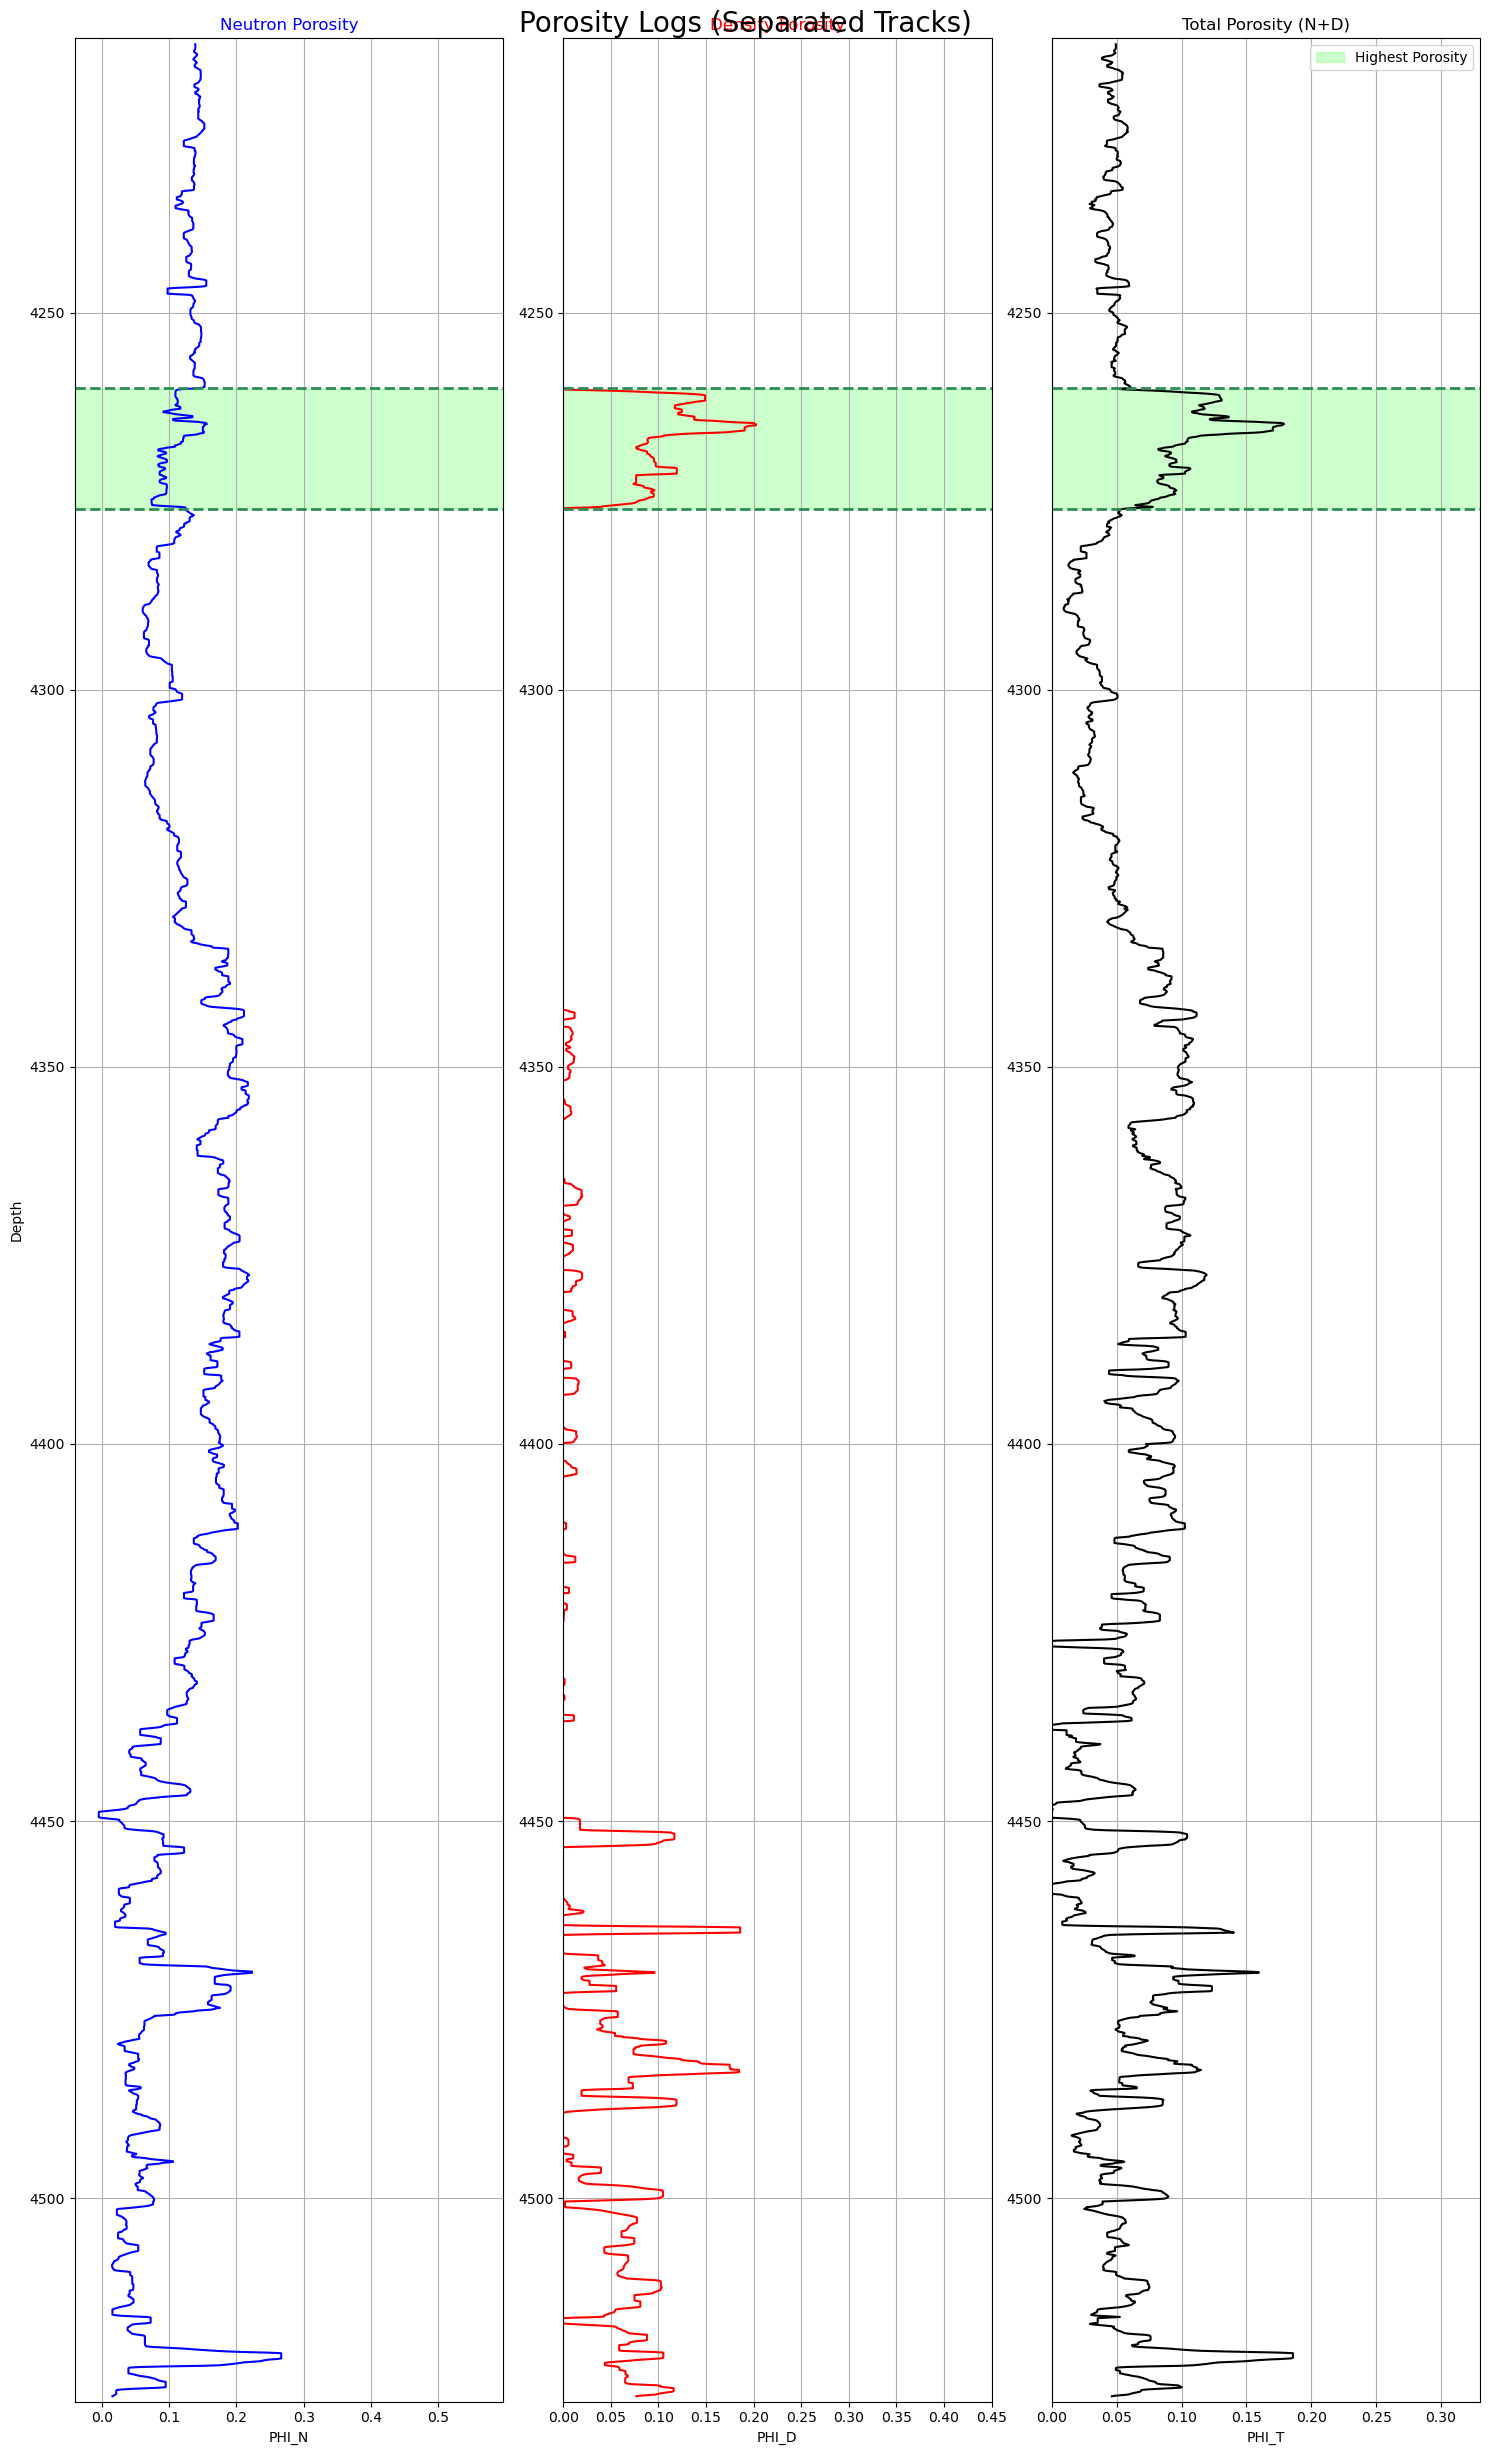

In [ ]:
poro_top=4260
poro_bottom=4276

fig, ax = plt.subplots(1, 3, figsize=(15, 25))

for axes in ax:
        axes.set_ylim(top_depth, bottom_depth)

ax[0].plot(df2['PHI_N'], df2['DEPTH'], color='blue')
ax[0].set_title('Neutron Porosity',color='blue')
ax[0].set_xlim(-0.04,0.596)
ax[0].invert_yaxis()
ax[0].set_xlabel('PHI_N')
ax[0].grid()

# Density
ax[1].plot(df2['PHI_D'], df2['DEPTH'], color='red')
ax[1].set_title('Density Porosity',color='red')
ax[1].set_xlim(0,0.45)
ax[1].invert_yaxis()
ax[1].set_xlabel('PHI_D')
ax[1].grid()

# Total Porosity
ax[2].plot(df2['PHI_T'], df2['DEPTH'], color='black')
ax[2].set_title('Total Porosity (N+D)',color='black')
ax[2].set_xlim(0,0.33)
ax[2].invert_yaxis()
ax[2].set_xlabel('PHI_T')
ax[2].grid()

for a in ax:
    a.axhline(poro_top, color='seagreen', linestyle='--', linewidth=2)
    a.axhline(poro_bottom, color='seagreen', linestyle='--', linewidth=2)

    a.fill_betweenx(
        df2['DEPTH'],
        a.get_xlim()[0],
        a.get_xlim()[1],
        where=(df2['DEPTH'] >=poro_top) & (df2['DEPTH'] <= poro_bottom),
        color="lime",
        label='Highest Porosity',
        alpha=0.2
    )

ax[0].set_ylabel('Depth')

plt.suptitle('Porosity Logs (Separated Tracks)', fontsize=20)
plt.legend()
plt.tight_layout()
plt.show()

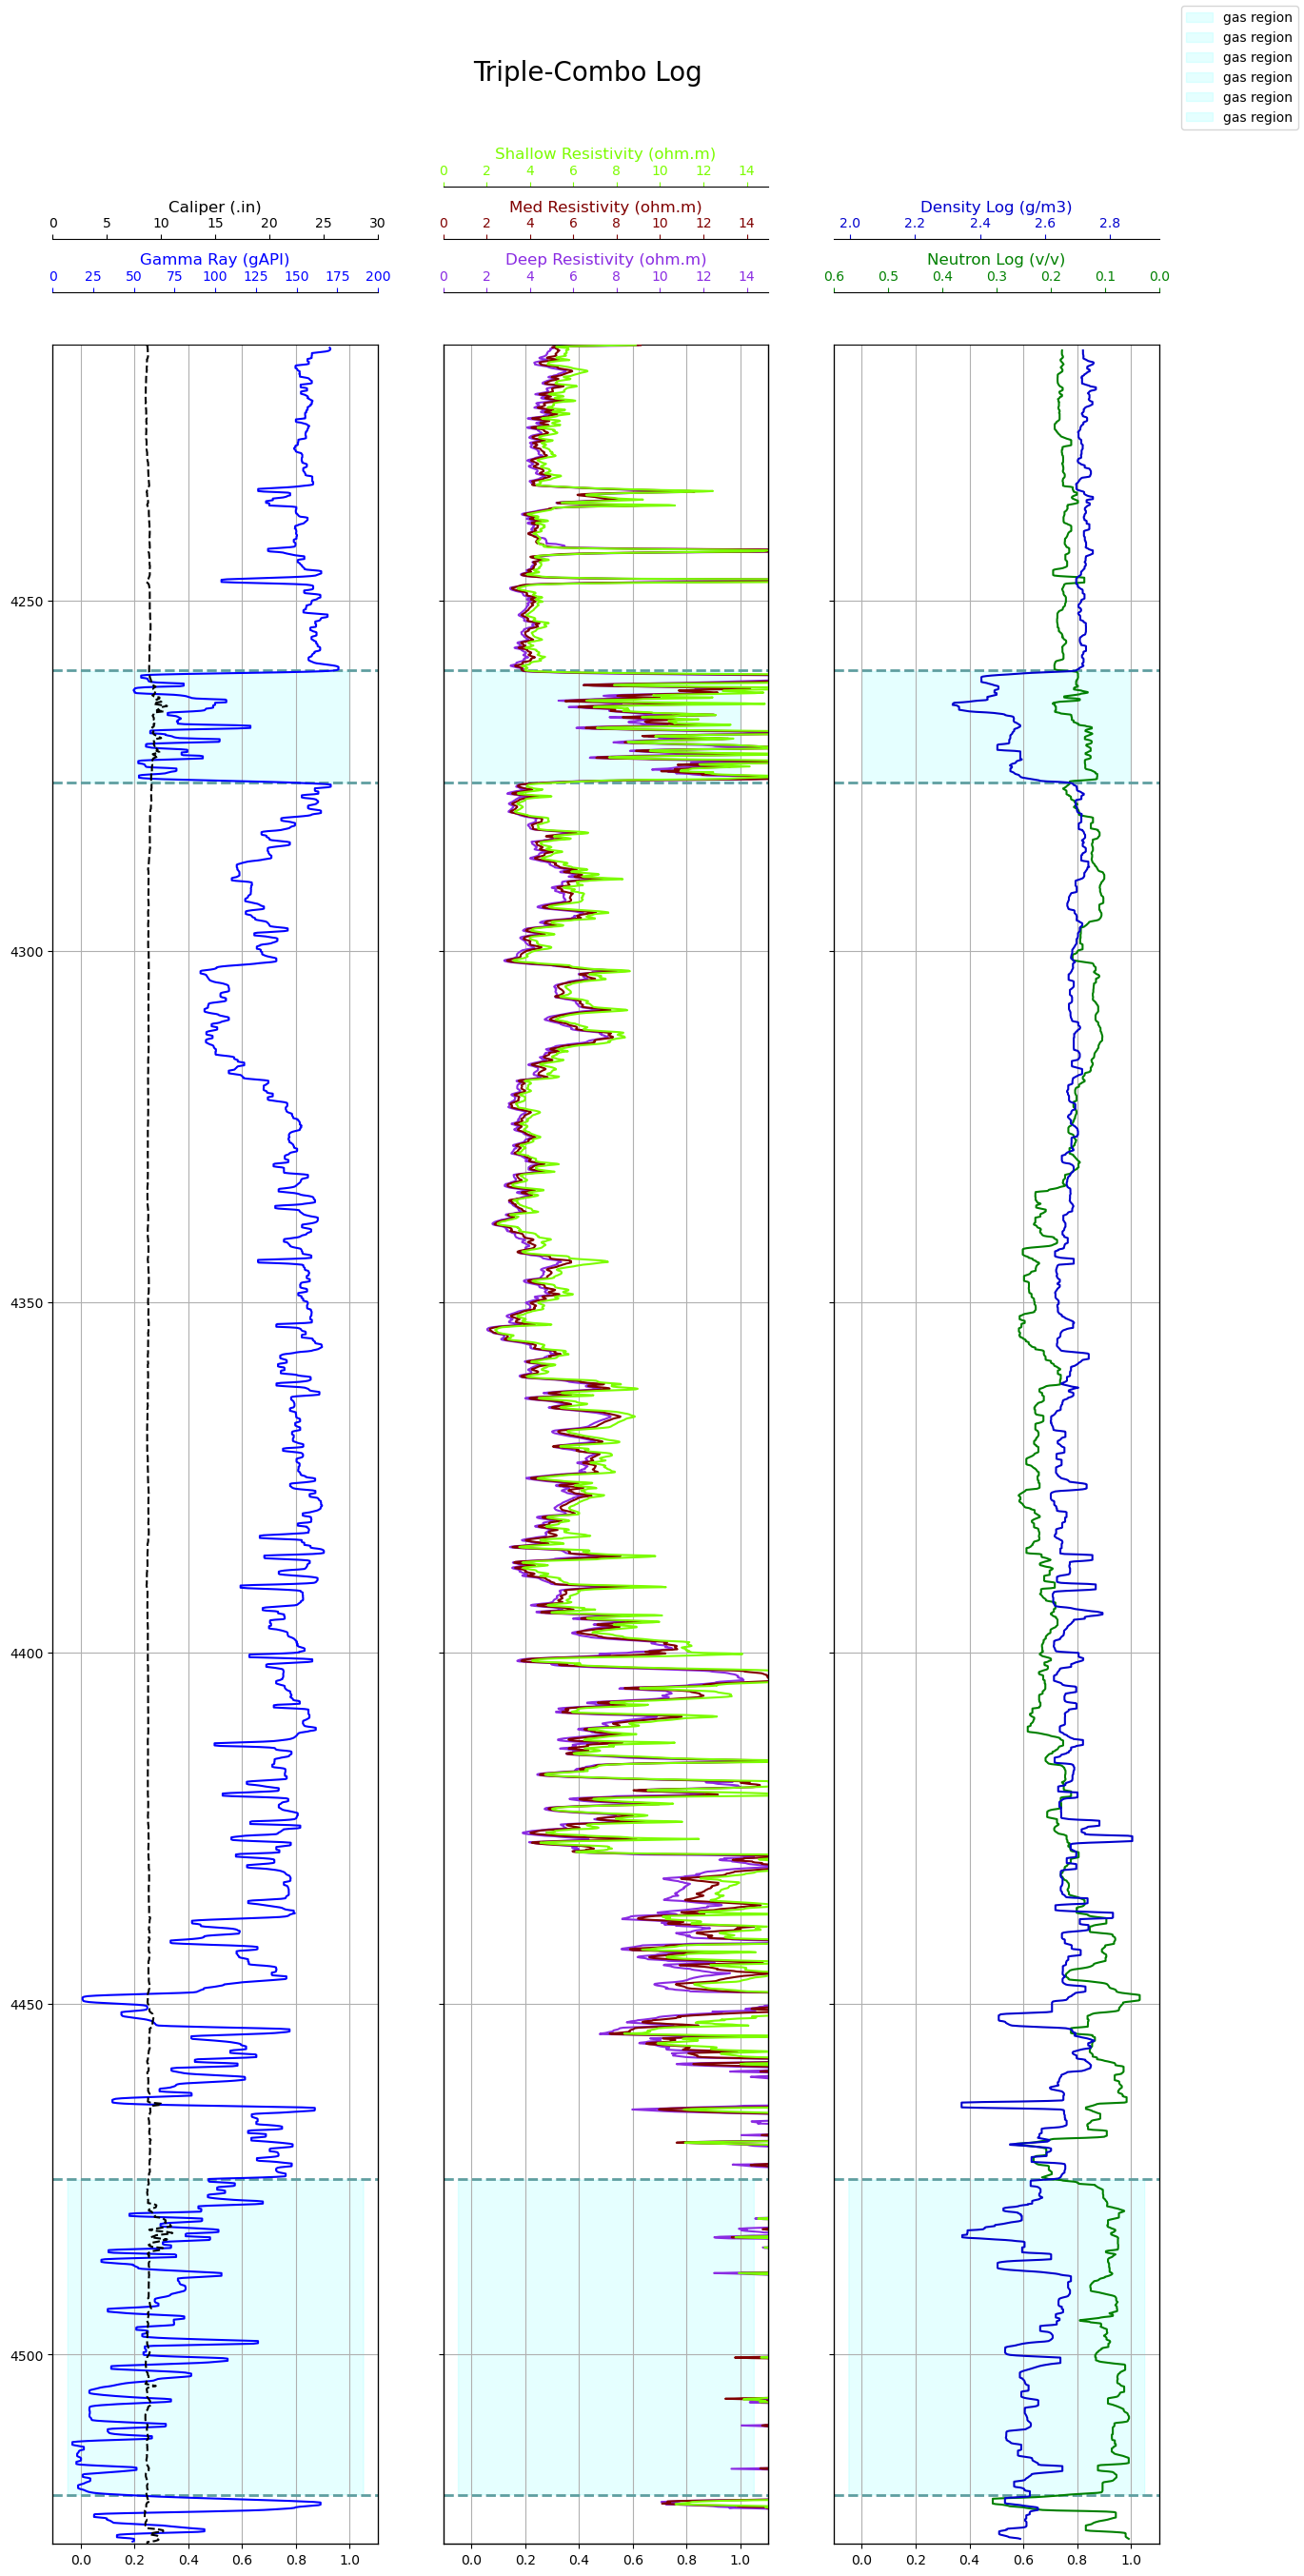

In [ ]:
gas_top=4260
gas_bottom=4276

gas1_top=4475
gas1_bottom=4520

fig, ac= plt.subplots(1,3,figsize=(15,30), sharey=True)

fig.suptitle('Triple-Combo Log', fontsize=20)
for axes in ac:
        axes.set_ylim(top_depth, bottom_depth)

ac2=ac[0].twiny()
ac2.plot(df2['GR_smooth'],df2['DEPTH'],color='blue')
ac2.set_xlim(0,200)
ac2.spines['top'].set_position(('outward',40))
ac2.set_xlabel('Gamma Ray (gAPI)',color='blue',fontsize=12)
ac2.tick_params(axis='x',colors='blue')

ac1=ac[0].twiny()
ac1.plot(df2['CALI'],df2['DEPTH'],color='black',linestyle='--')
ac1.set_xlim(0,30)
ac1.spines['top'].set_position(('outward',80))
ac1.set_xlabel('Caliper (.in)',color='black',fontsize=12)
ac1.tick_params(axis='x',colors='black')
ac[0].grid(True)


ac11=ac[1].twiny()
ac11.plot(df2['ILD'],df2['DEPTH'],color='blueviolet')
ac11.set_xlim(0,15)
ac11.spines['top'].set_position(('outward',40))
ac11.set_xlabel('Deep Resistivity (ohm.m)',color='blueviolet',fontsize=12)
ac11.tick_params(axis='x',colors='blueviolet')

ac12=ac[1].twiny()
ac12.plot(df2['ILM'],df2['DEPTH'],color='maroon')
ac12.set_xlim(0,15)
ac12.spines['top'].set_position(('outward',80))
ac12.set_xlabel('Med Resistivity (ohm.m)',color='maroon',fontsize=12)
ac12.tick_params(axis='x',colors='maroon')

ac13=ac[1].twiny()
ac13.plot(df2['ILS'],df2['DEPTH'],color='lawngreen')
ac13.set_xlim(0,15)
ac13.spines['top'].set_position(('outward',120))
ac13.set_xlabel('Shallow Resistivity (ohm.m)',color='lawngreen',fontsize=12)
ac13.tick_params(axis='x',colors='lawngreen')
ac[1].grid(True)


ac21=ac[2].twiny()
ac21.plot(df2['NPHI_smooth'],df2['DEPTH'],color='green')
ac21.set_xlim(0,0.6)
ac21.invert_xaxis()
ac21.spines['top'].set_position(('outward',40))
ac21.set_xlabel('Neutron Log (v/v)',color='green',fontsize=12)
ac21.tick_params(axis='x',colors='green')

ac22=ac[2].twiny()
ac22.plot(df2['RHOB_smooth'],df2['DEPTH'],color='mediumblue')
ac22.set_xlim(1.95,2.95)
ac22.spines['top'].set_position(('outward',80))
ac22.set_xlabel('Density Log (g/m3)',color='mediumblue',fontsize=12)
ac22.tick_params(axis='x',colors='mediumblue')
ac[2].grid(True)

for axes in ac:
    axes.axhline(gas_top, color='cadetblue', linestyle='--', linewidth=2)
    axes.axhline(gas_bottom, color='cadetblue', linestyle='--', linewidth=2)

    axes.fill_betweenx(
        df2['DEPTH'],
        axes.get_xlim()[0],
        axes.get_xlim()[1],
        where=(df2['DEPTH'] >=gas_top) & (df2['DEPTH'] <= gas_bottom),
        color="aqua",
        label='gas region',
        alpha=0.1
    )

for axes in ac:
    axes.axhline(gas1_top, color='cadetblue', linestyle='--', linewidth=2)
    axes.axhline(gas1_bottom, color='cadetblue', linestyle='--', linewidth=2)

    axes.fill_betweenx(
        df2['DEPTH'],
        axes.get_xlim()[0],
        axes.get_xlim()[1],
        where=(df2['DEPTH'] >=gas1_top) & (df2['DEPTH'] <= gas1_bottom),
        color="aqua",
        label='gas region',
        alpha=0.1
    )

fig.legend()
plt.gca().invert_yaxis()

In [ ]:
GRmin= np.percentile(df2['GR'],5)
GRmax= np.percentile(df2['GR'],95)

df2['IGR'] = (df2['GR'] - GRmin)/(GRmax - GRmin)

df2["VSH"] = df2['IGR']

In [ ]:
sfs = df2[(df2['VSH'] <= 0.4) & (df2['DEPTH'] >= top_depth) & (df2['DEPTH'] <= bottom_depth)]

In [ ]:
sfd = sfs.copy()

sfd = sfd[sfd['PHI_T'] > 0]
sfd['y_val'] = np.log(sfd['PHI_T'] / 0.4)
sf = sfd.dropna(subset=['y_val', 'DEPTH'])

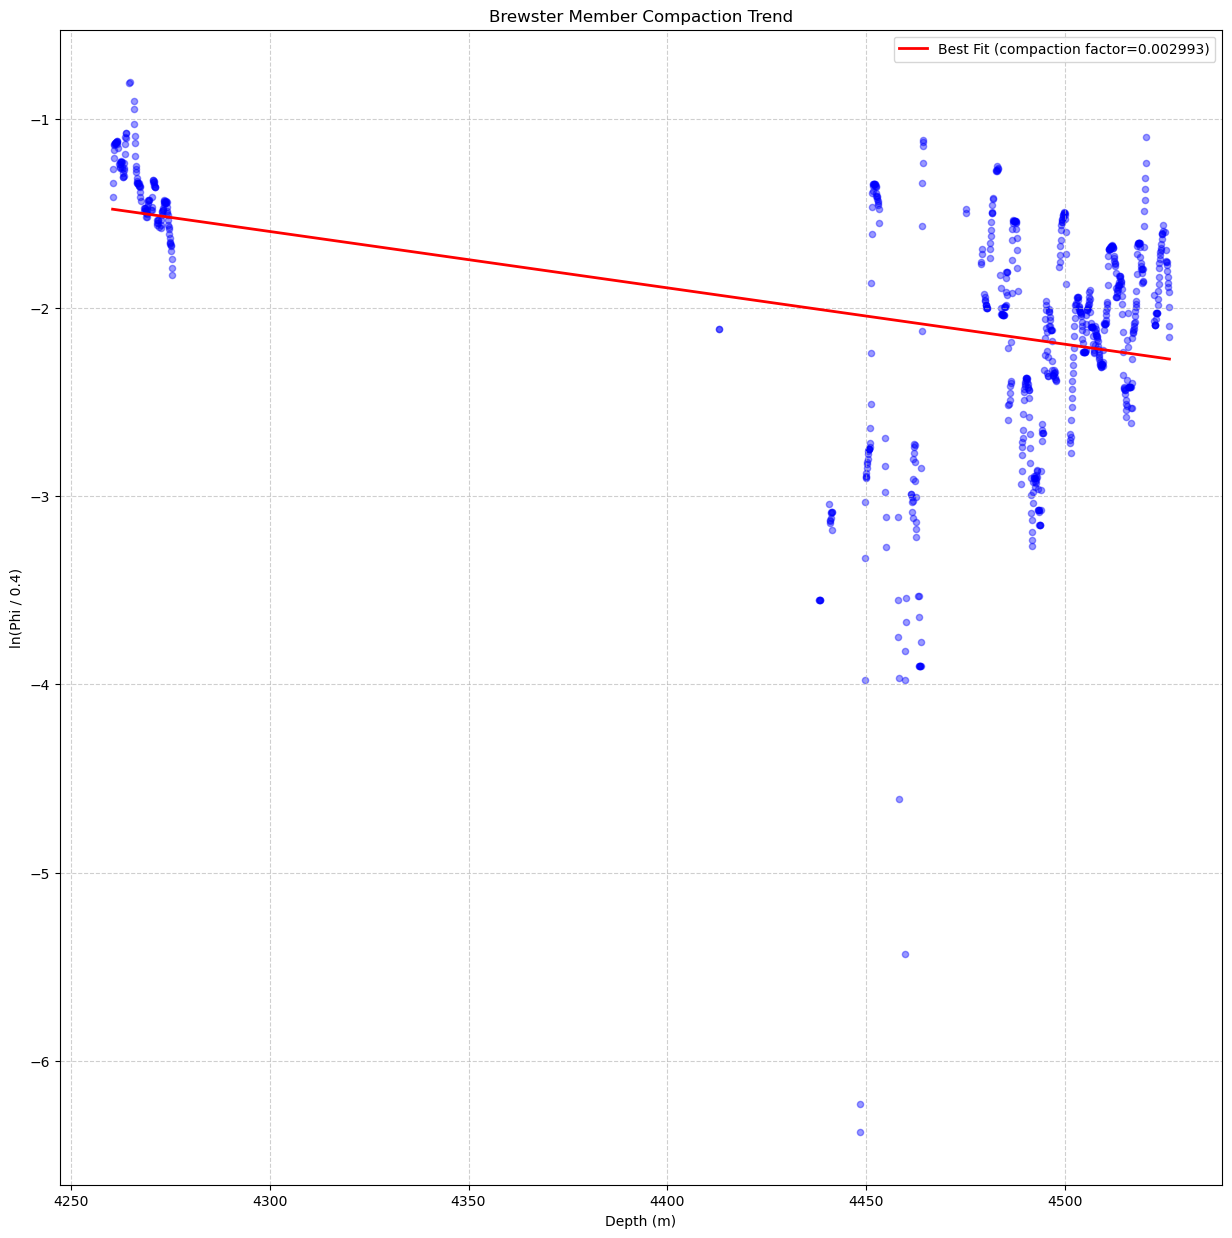

In [ ]:
y = np.log(sf['PHI_T'] / 0.4)
x = sf['DEPTH']

plt.figure(figsize=(15,15))
m,b=np.polyfit(x,y,1)
plt.scatter(x,y,alpha=0.4,s=20,color='blue')
plt.plot(x, m*x + b, color='red', linewidth=2, label=f'Best Fit (compaction factor={-m:.6f})')

plt.xlabel('Depth (m)')
plt.ylabel('ln(Phi / 0.4)')
plt.title('Brewster Member Compaction Trend')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
df4['Vp']= 304800/df4['DTCO']
df4['Vs']= 304800/df4['DTSM']

In [ ]:
df = pd.merge(df2, df4[['DEPTH', 'Vp','Vs']], on='DEPTH', how='inner')

df['AI'] = df['Vp'] * df['RHOB']
df['SI'] = df['Vs'] * df['RHOB']

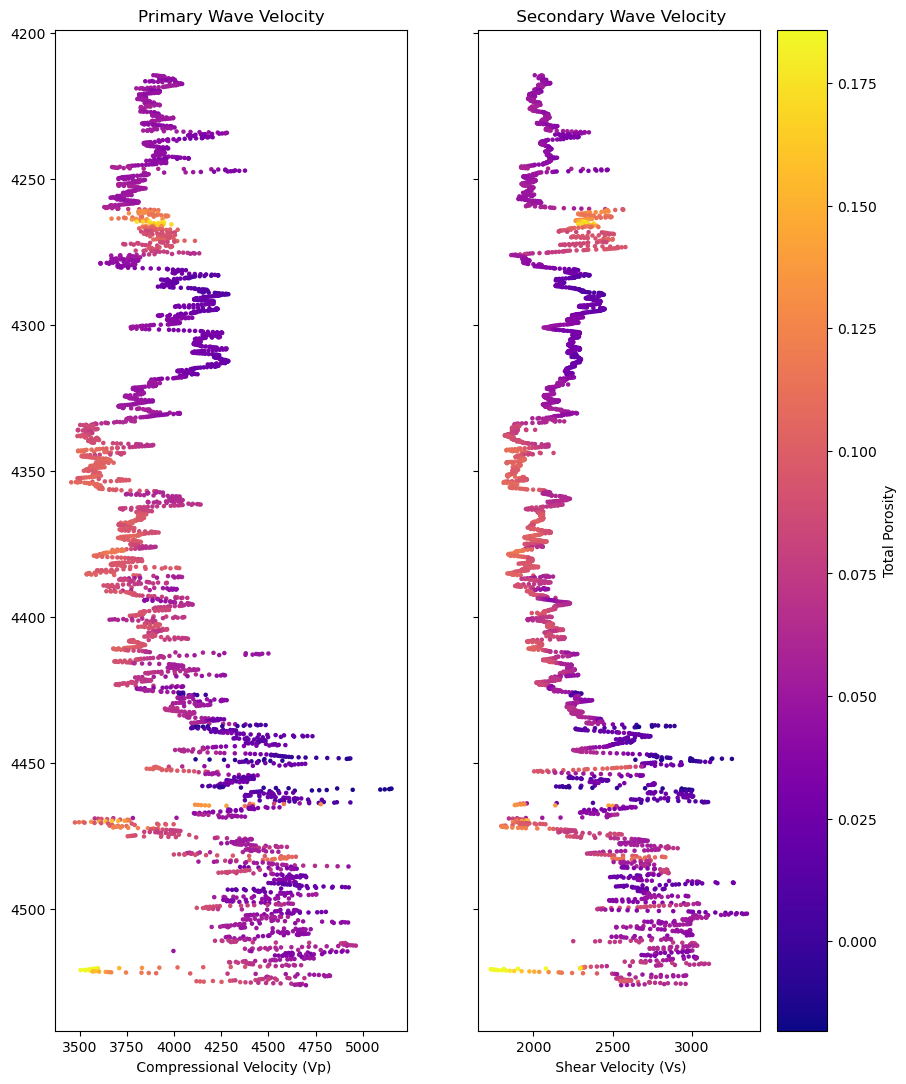

In [ ]:
fig,ax = plt.subplots(1,2, figsize=(10,13), sharey= True)

vp = ax[0].scatter(df['Vp'],df['DEPTH'],c=df['PHI_T'], cmap='plasma', s=5)
ax[0].set_xlabel(' Compressional Velocity (Vp)')
ax[0].set_title('Primary Wave Velocity')

vs = ax[1].scatter(df['Vs'],df['DEPTH'],c=df['PHI_T'], cmap='plasma' , s=5)
ax[1].set_xlabel(' Shear Velocity (Vs)')
ax[1].set_title(' Secondary Wave Velocity')

ax[0].invert_yaxis()
fig.colorbar(vp,ax=ax[1], label='Total Porosity')
plt.show()

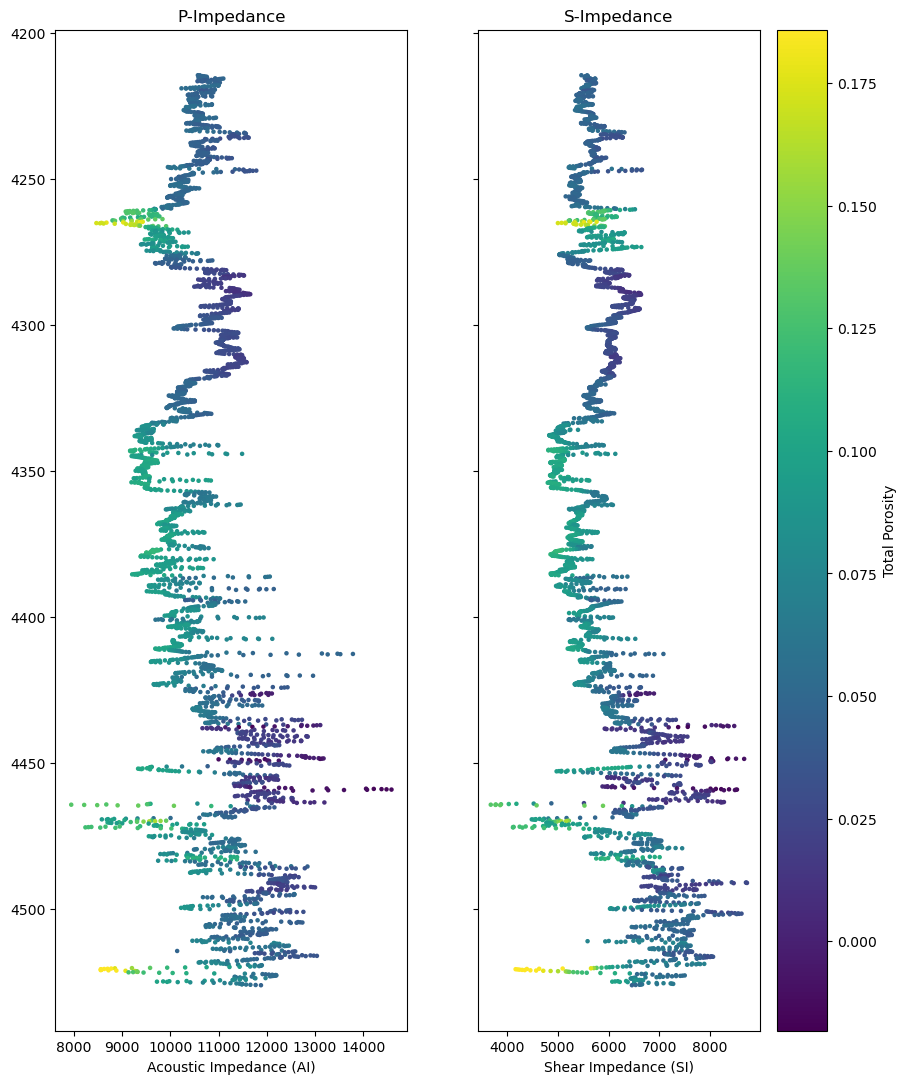

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 13), sharey=True)

im1 = ax[0].scatter(df['AI'], df['DEPTH'],
                     c=df['PHI_T'], cmap='viridis', s=5)
ax[0].set_xlabel('Acoustic Impedance (AI)')
ax[0].set_title('P-Impedance')

im2 = ax[1].scatter(df['SI'], df['DEPTH'],
                     c=df['PHI_T'], cmap='viridis', s=5)
ax[1].set_xlabel('Shear Impedance (SI)')
ax[1].set_title('S-Impedance')

ax[0].invert_yaxis()
fig.colorbar(im2, ax=ax[1], label='Total Porosity')
plt.show()

In [ ]:
df['RC']=df['AI'].diff() / (df['AI'].shift(-1) + df['AI'])
df['RC'] = df['RC'].fillna(0)

In [ ]:
def ricker(f, length, dt):
    t = np.arange(-length/2, length/2, dt)
    y = (1.0 - 2.0*(np.pi**2)*(f**2)*(t**2)) * np.exp(-(np.pi**2)*(f**2)*(t**2))
    return t, y

f = 25
dt = 0.001
t, wavelet = ricker(f, 0.128, dt)

In [ ]:
df['synthetic'] = np.convolve(df['RC'], wavelet, mode='same')

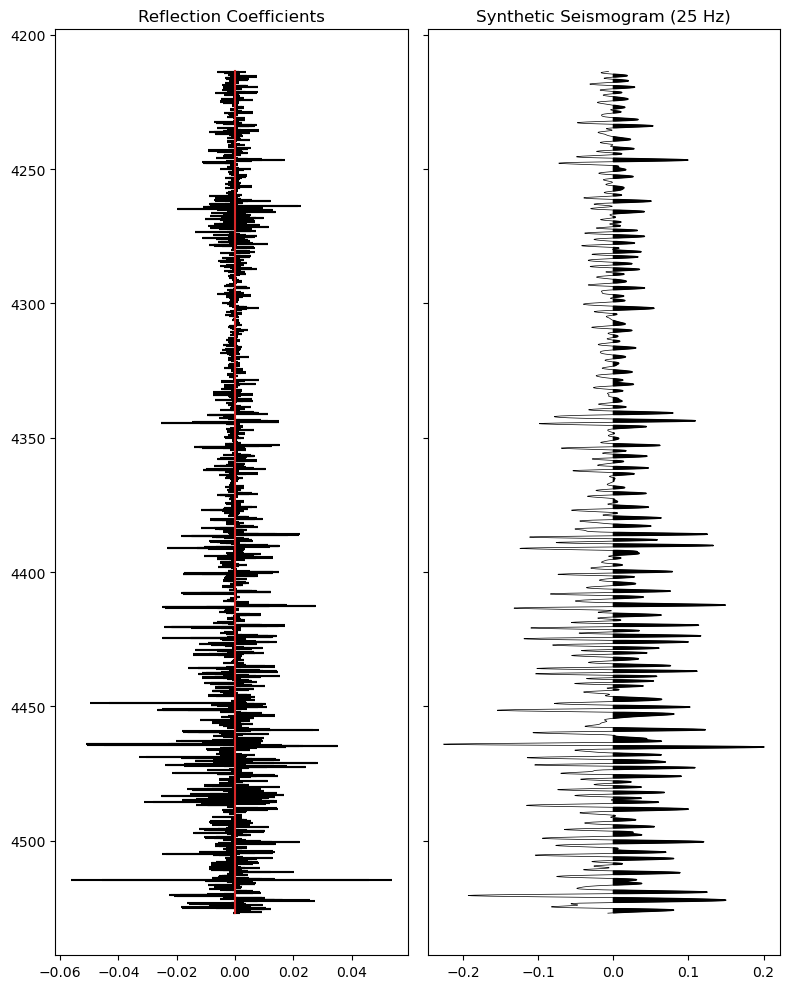

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 10), sharey=True)

ax[0].stem(df['DEPTH'], df['RC'], markerfmt=' ', linefmt='black', orientation='horizontal')
ax[0].set_title('Reflection Coefficients')

ax[1].plot(df['synthetic'], df['DEPTH'], color='black', lw=0.5)
ax[1].fill_betweenx(df['DEPTH'], 0, df['synthetic'], where=(df['synthetic'] > 0), color='black')
ax[1].set_title('Synthetic Seismogram (25 Hz)')

ax[0].invert_yaxis()
plt.tight_layout()
plt.show()

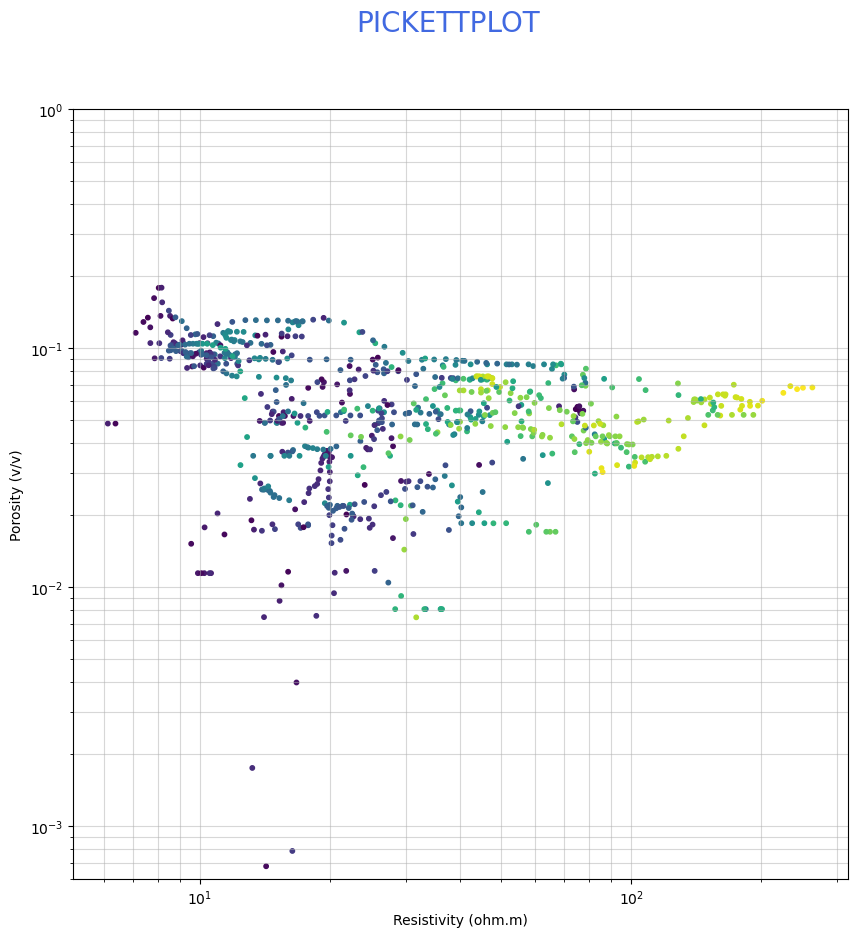

In [ ]:
plt.figure(figsize=(10,10))
plt.suptitle('PICKETTPLOT',fontsize=20,color='royalblue')
plt.scatter(sf['ILD'],sf['PHI_T'],c=sf['VSH'],cmap='viridis_r',s=10)

plt.xscale("log")
plt.yscale("log")

plt.xlabel('Resistivity (ohm.m)')
plt.ylabel('Porosity (v/v)')
plt.ylim(0.0006,1)
plt.grid(True, which="both", ls="-", alpha=0.5)

In [ ]:
#From the Pickettplot, using the water line, we can assume that when Porosity is 1, Resistivity would be around 0.01 ohm.m
# Putting that as Rw= Rt= 0.01ohm.m

Rw=0.04

In [ ]:
df['Sw'] = np.sqrt((1 * Rw) / (df['PHI_T']**2 * df['ILD']))

df['Sw'] = df['Sw'].clip(0, 1)

In [ ]:
df['Reservoir_Flag'] = ((df['VSH'] <= 0.4) & (df['Sw'] <= 0.7)).astype(int)

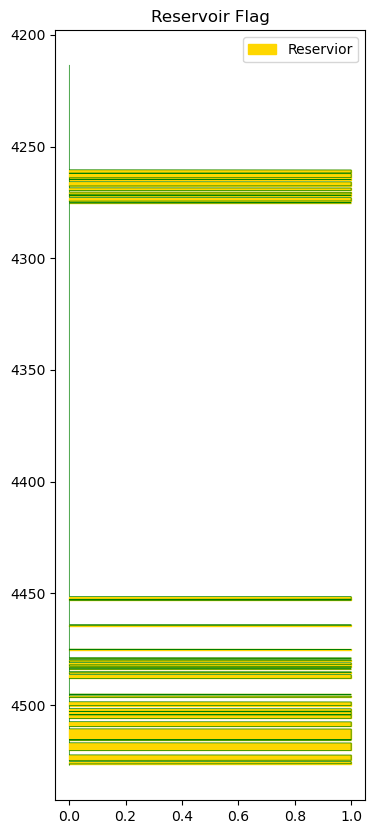

In [ ]:
plt.figure(figsize=(4, 10))
plt.plot(df['Reservoir_Flag'], df['DEPTH'], color='green',lw=0.5)
plt.fill_betweenx(df['DEPTH'], 0, df['Reservoir_Flag'], where=(df['Reservoir_Flag'] == 1), color='gold', label='Reservior')

plt.gca().invert_yaxis()
plt.title('Reservoir Flag')
plt.legend()
plt.show()

In [ ]:
sample_rate = 0.0762

net_pay = df['Reservoir_Flag'].sum() * sample_rate

print(f"Total Net Pay in Brewster Member: {net_pay:.2f} meters")

Total Net Pay in Brewster Member: 36.58 meters


In [ ]:
df['PHI_E'] = df['PHI_T'] * (1 - df['VSH'])

In [ ]:
pay_zone_data = df[df['Reservoir_Flag'] == 1]

stats_summary = pay_zone_data[['PHI_E', 'Sw', 'VSH']].agg(['mean', 'std'])

print("--- Reservoir Zone Statistics (Task 8) ---")
print(stats_summary)

--- Reservoir Zone Statistics (Task 8) ---
         PHI_E        Sw       VSH
mean  0.066781  0.492171  0.094972
std   0.018736  0.129424  0.171296


In [ ]:
#thank you :)